# 01 — Exploratory Data Analysis & Cleaning

**Input:** `cs-training.csv` (place in same folder as this notebook)  
**Output:** `data/cs_clean.parquet`

---

In [2]:
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
warnings.filterwarnings('ignore')
%matplotlib inline

os.makedirs('data',    exist_ok=True)
os.makedirs('models',  exist_ok=True)
os.makedirs('reports', exist_ok=True)

plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,'axes.spines.right':False,
                     'axes.titlesize':13,'axes.labelsize':11})
PAL  = {'good':'#1D9E75','bad':'#D85A30','neutral':'#378ADD'}
SEED = 42
DLQ  = ['past_due_30_59','past_due_60_89','times_90d_late']

print('Setup complete ✓')

Setup complete ✓


## 1. Load Data

In [3]:
RENAME = {
    'SeriousDlqin2yrs':                        'default',
    'RevolvingUtilizationOfUnsecuredLines':     'revolving_utilization',
    'age':                                      'age',
    'NumberOfTime30-59DaysPastDueNotWorse':     'past_due_30_59',
    'DebtRatio':                                'debt_ratio',
    'MonthlyIncome':                            'monthly_income',
    'NumberOfOpenCreditLinesAndLoans':          'open_credit_lines',
    'NumberOfTimes90DaysLate':                  'times_90d_late',
    'NumberRealEstateLoansOrLines':             'real_estate_loans',
    'NumberOfTime60-89DaysPastDueNotWorse':     'past_due_60_89',
    'NumberOfDependents':                       'dependents'
}

df = pd.read_csv('cs-training.csv', index_col=0).rename(columns=RENAME)
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'Default rate: {df["default"].mean()*100:.2f}%')
df.head()

Shape: 150,000 rows x 11 cols
Default rate: 6.68%


,default,revolving_utilization,age,past_due_30_59,debt_ratio,monthly_income,open_credit_lines,times_90d_late,real_estate_loans,past_due_60_89,dependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [4]:
df.describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T\
  .style.format(precision=2).background_gradient(cmap='Blues',subset=['mean','std'])

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
default,150000.00,0.07,0.25,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00
revolving_utilization,150000.00,6.05,249.76,0.00,0.00,0.00,0.03,0.15,0.56,1.00,1.09,50708.00
age,150000.00,52.30,14.77,0.00,24.00,29.00,41.00,52.00,63.00,78.00,87.00,109.00
past_due_30_59,150000.00,0.42,4.19,0.00,0.00,0.00,0.00,0.00,0.00,2.00,4.00,98.00
debt_ratio,150000.00,353.01,2037.82,0.00,0.00,0.00,0.18,0.37,0.87,2449.00,4979.04,329664.00
monthly_income,120269.00,6670.22,14384.67,0.00,0.00,1300.00,3400.00,5400.00,8249.00,14587.60,25000.00,3008750.00
open_credit_lines,150000.00,8.45,5.15,0.00,0.00,2.00,5.00,8.00,11.00,18.00,24.00,58.00
times_90d_late,150000.00,0.27,4.17,0.00,0.00,0.00,0.00,0.00,0.00,1.00,3.00,98.00
real_estate_loans,150000.00,1.02,1.13,0.00,0.00,0.00,0.00,1.00,2.00,3.00,4.00,54.00
past_due_60_89,150000.00,0.24,4.16,0.00,0.00,0.00,0.00,0.00,0.00,1.00,2.00,98.00


## 2. Missing Values

,n_missing,pct
monthly_income,"29,731",19.82%
dependents,"3,924",2.62%


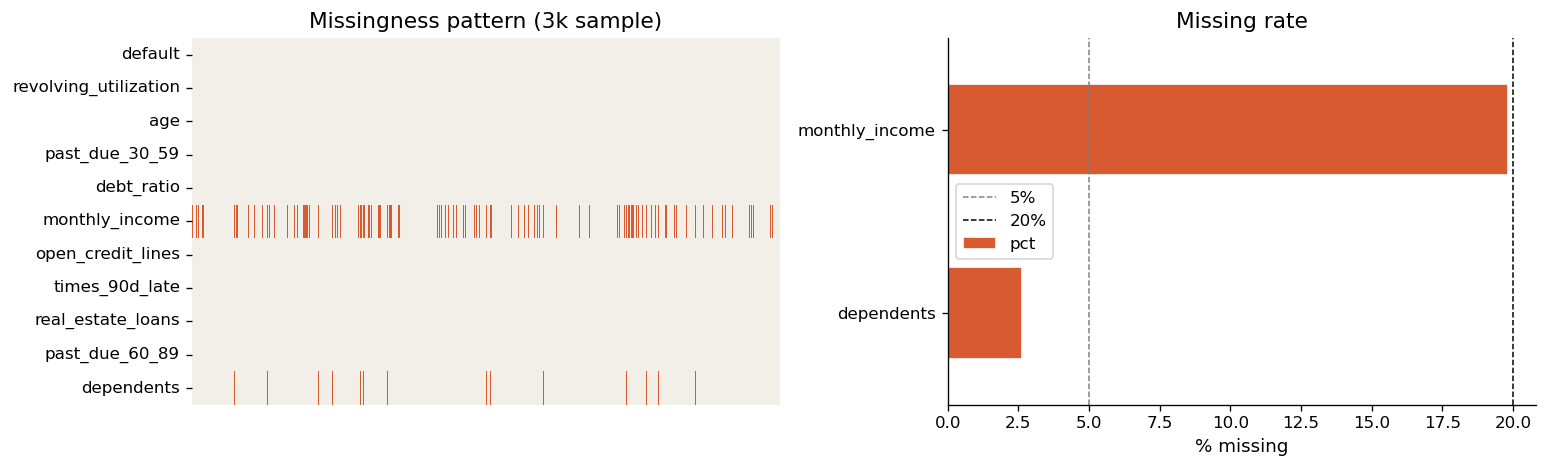

In [5]:
miss = df.isnull().sum().rename('n_missing').to_frame()
miss['pct'] = miss['n_missing'] / len(df) * 100
miss = miss[miss['n_missing']>0].sort_values('pct',ascending=False)
display(miss.style.format({'pct':'{:.2f}%','n_missing':'{:,}'}).bar(subset='pct',color=PAL['bad']))

fig, axes = plt.subplots(1,2,figsize=(13,4))
sns.heatmap(df.sample(3000,random_state=SEED).isnull().T, ax=axes[0],
            cbar=False, cmap=['#F1EFE8',PAL['bad']], xticklabels=False)
axes[0].set_title('Missingness pattern (3k sample)')
miss['pct'].sort_values().plot.barh(ax=axes[1], color=PAL['bad'], edgecolor='white')
axes[1].axvline(5,  color='gray',  ls='--', lw=0.9, label='5%')
axes[1].axvline(20, color='black', ls='--', lw=0.9, label='20%')
axes[1].set_xlabel('% missing'); axes[1].set_title('Missing rate'); axes[1].legend()
plt.tight_layout()
plt.savefig('reports/missing.png', bbox_inches='tight')
plt.show()

In [6]:
df['_inc_miss'] = df['monthly_income'].isnull().astype(int)
ct = pd.crosstab(df['_inc_miss'], df['default'])
chi2, p, _, _ = stats.chi2_contingency(ct)
print(f'Chi-square MCAR test — chi2={chi2:.2f}, p={p:.4e}')
print('=> Missingness is NOT random (MAR).' if p < 0.05 else '=> Missingness appears random.')
df.drop(columns='_inc_miss', inplace=True)

Chi-square MCAR test — chi2=67.89, p=1.7262e-16
=> Missingness is NOT random (MAR).


## 3. Class Imbalance

No default: 139,974 (93.3%)
Default:    10,026 (6.7%)
Imbalance ratio: 14.0:1


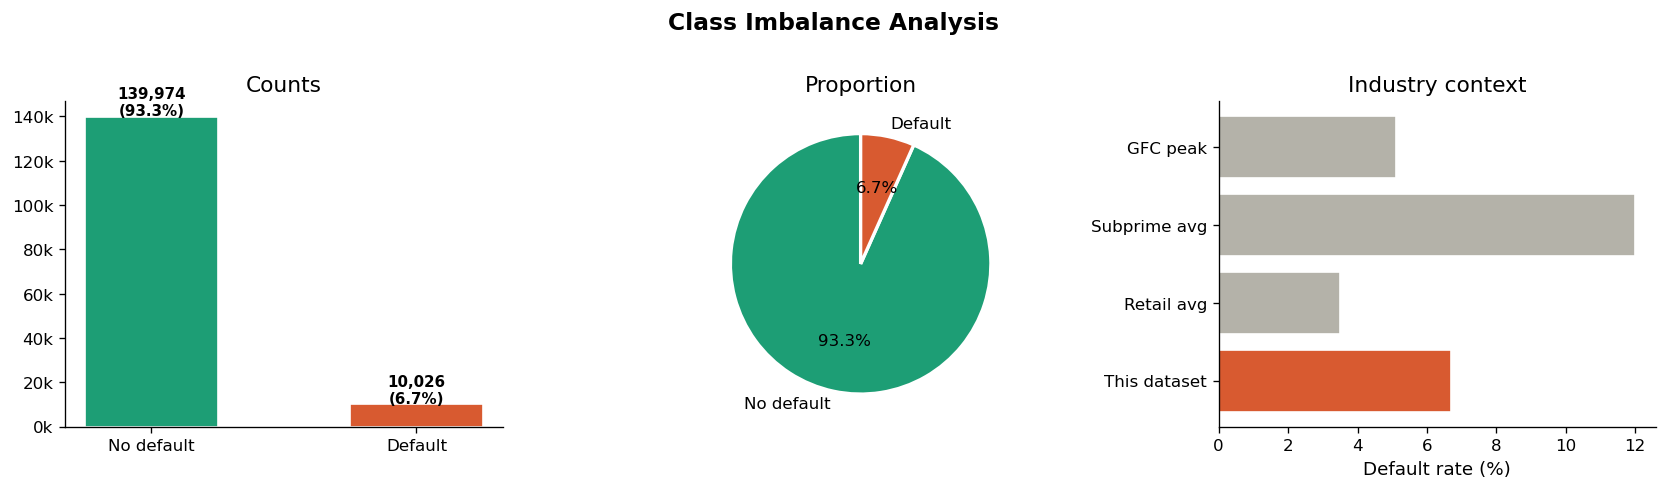

In [7]:
counts = df['default'].value_counts()
pcts   = df['default'].value_counts(normalize=True) * 100
print(f'No default: {counts[0]:,} ({pcts[0]:.1f}%)')
print(f'Default:    {counts[1]:,} ({pcts[1]:.1f}%)')
print(f'Imbalance ratio: {counts[0]/counts[1]:.1f}:1')

fig, axes = plt.subplots(1,3,figsize=(14,4))
axes[0].bar(['No default','Default'], counts.values,
             color=[PAL['good'],PAL['bad']], edgecolor='white', width=0.5)
for bar,c,p in zip(axes[0].patches, counts.values, pcts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+400,
                 f'{c:,}\n({p:.1f}%)', ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Counts')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}k'))
axes[1].pie(counts.values, labels=['No default','Default'],
             colors=[PAL['good'],PAL['bad']], autopct='%1.1f%%', startangle=90,
             wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Proportion')
ref   = {'This dataset':pcts[1],'Retail avg':3.5,'Subprime avg':12.0,'GFC peak':5.1}
rcols = [PAL['bad'] if k=='This dataset' else '#B4B2A9' for k in ref]
axes[2].barh(list(ref.keys()), list(ref.values()), color=rcols, edgecolor='white')
axes[2].set_xlabel('Default rate (%)'); axes[2].set_title('Industry context')
plt.suptitle('Class Imbalance Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('reports/class_imbalance.png', bbox_inches='tight')
plt.show()

## 4. Feature Distributions

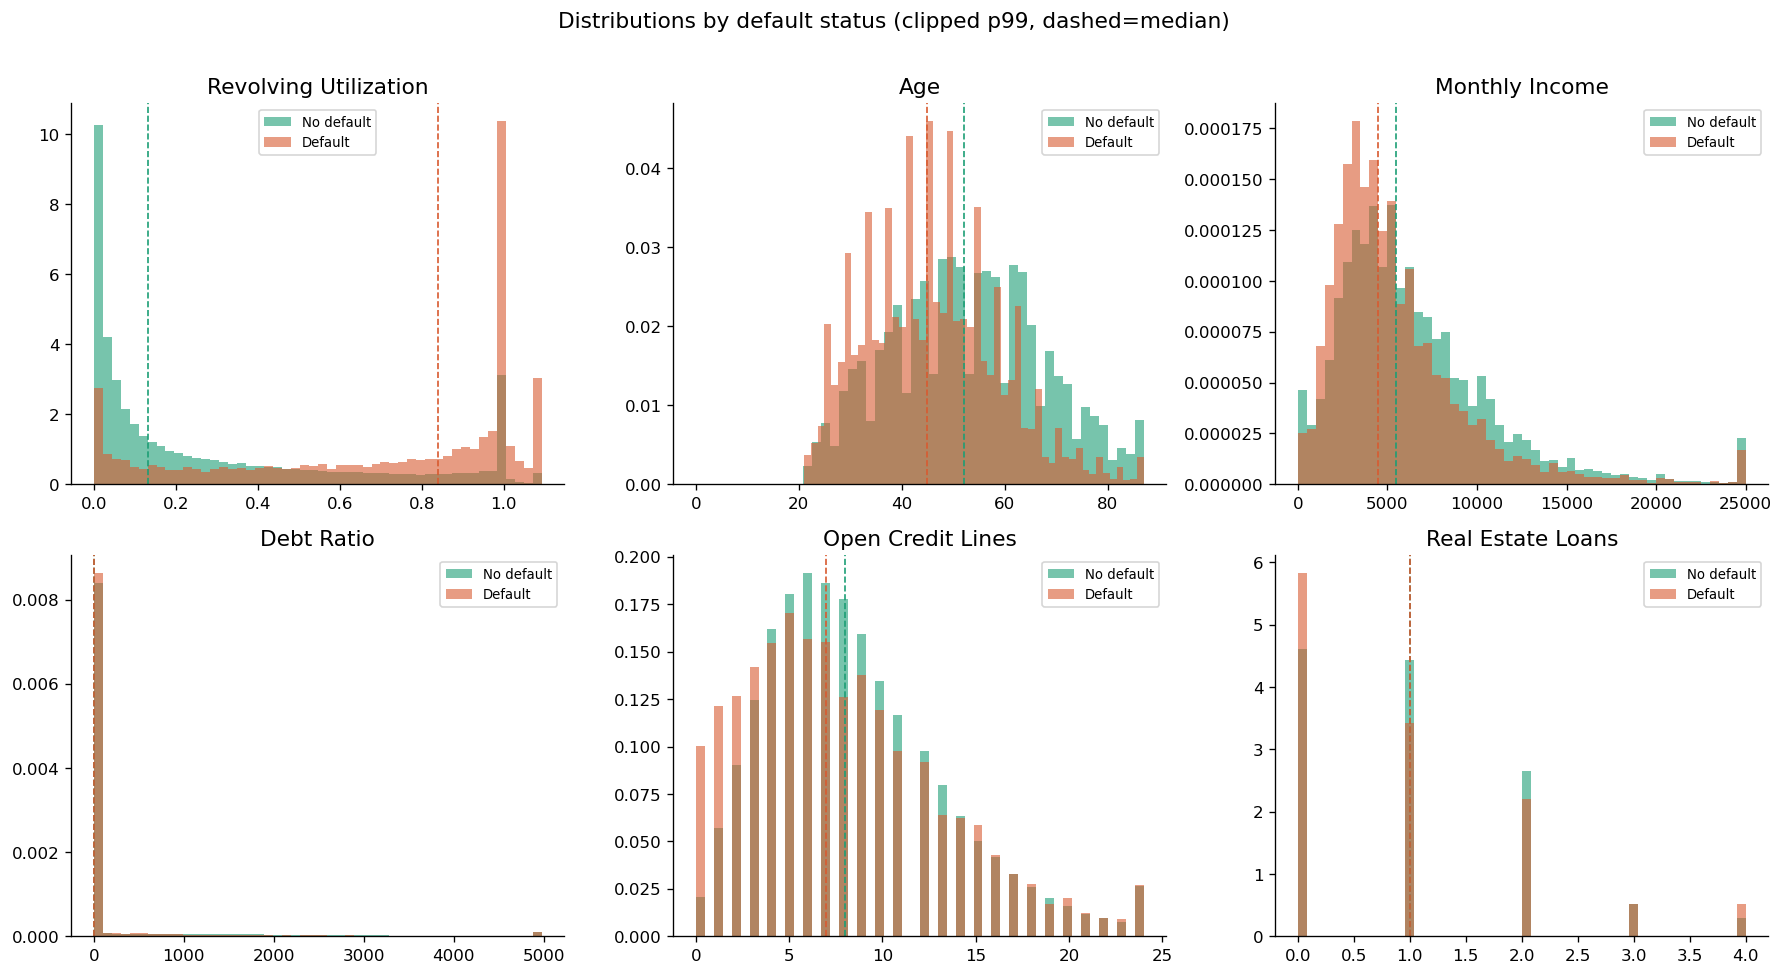

In [8]:
good  = df[df['default']==0]; bad = df[df['default']==1]
FEATS = ['revolving_utilization','age','monthly_income',
         'debt_ratio','open_credit_lines','real_estate_loans']

fig, axes = plt.subplots(2,3,figsize=(15,8))
for ax,feat in zip(axes.flatten(), FEATS):
    clip = df[feat].quantile(0.99)
    ax.hist(good[feat].clip(upper=clip).dropna(), bins=50, color=PAL['good'], alpha=0.6, density=True, label='No default')
    ax.hist(bad[feat].clip(upper=clip).dropna(),  bins=50, color=PAL['bad'],  alpha=0.6, density=True, label='Default')
    ax.axvline(good[feat].median(), color=PAL['good'], ls='--', lw=1)
    ax.axvline(bad[feat].median(),  color=PAL['bad'],  ls='--', lw=1)
    ax.set_title(feat.replace('_',' ').title()); ax.legend(fontsize=8)
plt.suptitle('Distributions by default status (clipped p99, dashed=median)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('reports/distributions.png', bbox_inches='tight')
plt.show()

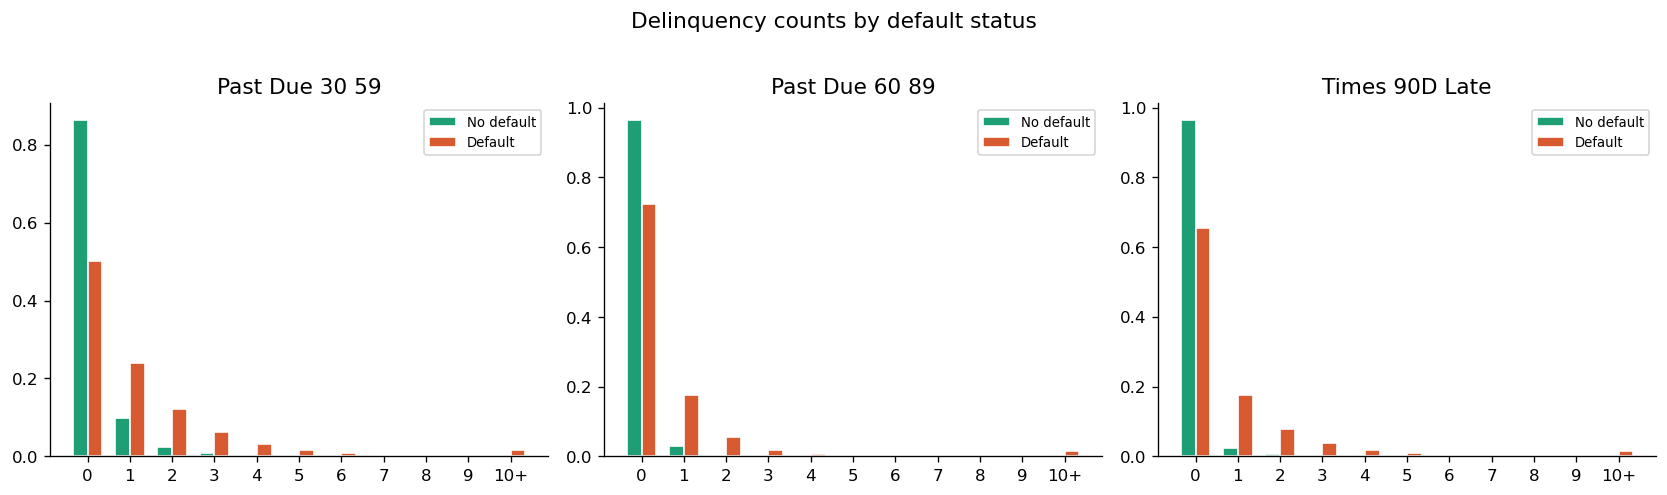

In [9]:
fig, axes = plt.subplots(1,3,figsize=(14,4))
for ax,feat in zip(axes, DLQ):
    vc_g = good[feat].clip(upper=10).value_counts(normalize=True).sort_index()
    vc_b = bad[feat].clip(upper=10).value_counts(normalize=True).sort_index()
    all_v = sorted(set(vc_g.index)|set(vc_b.index)); x=np.arange(len(all_v)); w=0.35
    ax.bar(x-w/2, [vc_g.get(v,0) for v in all_v], width=w, color=PAL['good'], label='No default', edgecolor='white')
    ax.bar(x+w/2, [vc_b.get(v,0) for v in all_v], width=w, color=PAL['bad'],  label='Default',    edgecolor='white')
    ax.set_xticks(x); ax.set_xticklabels([str(v) if v<10 else '10+' for v in all_v])
    ax.set_title(feat.replace('_',' ').title()); ax.legend(fontsize=8)
plt.suptitle('Delinquency counts by default status', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('reports/delinquency.png', bbox_inches='tight')
plt.show()

## 5. Correlation Analysis

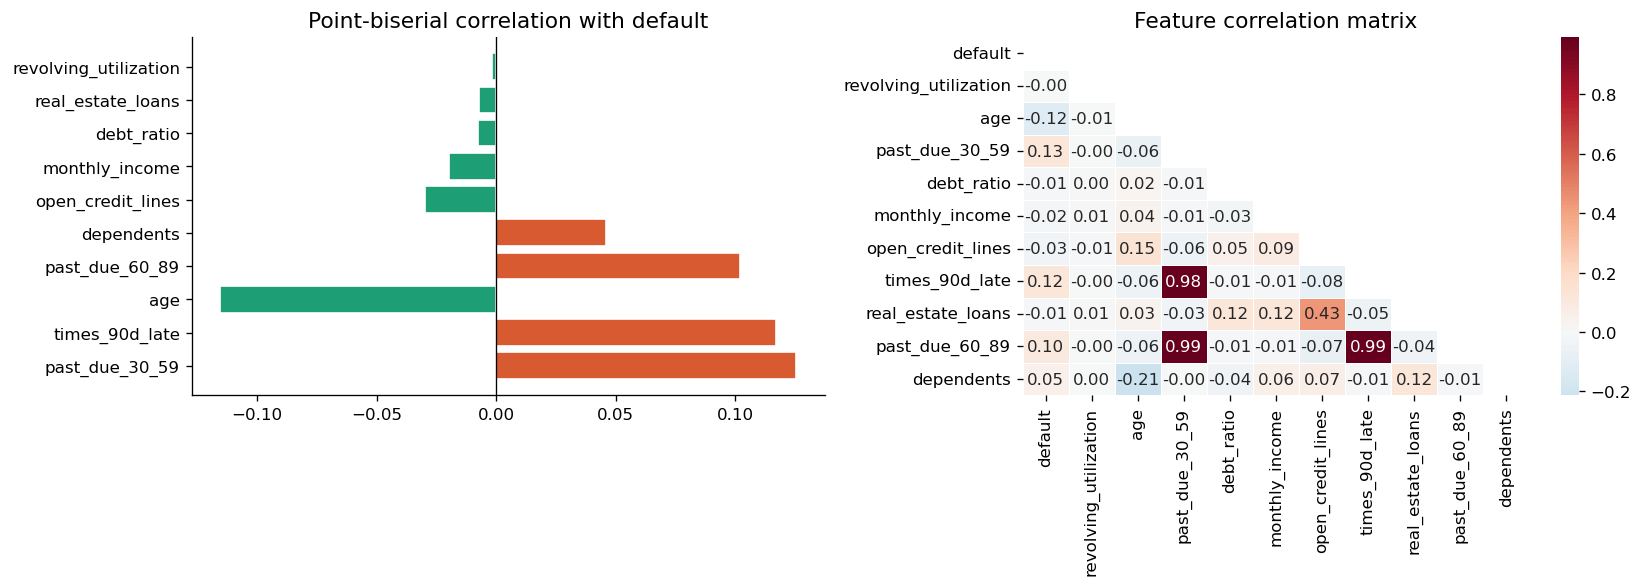

In [10]:
corr_res = []
for feat in [c for c in df.columns if c != 'default']:
    cl = df[[feat,'default']].dropna()
    r, p = stats.pointbiserialr(cl[feat], cl['default'])
    corr_res.append({'feature':feat,'correlation':r,'p_value':p})
corr_df = pd.DataFrame(corr_res).set_index('feature').sort_values('correlation',key=abs,ascending=False)

fig, axes = plt.subplots(1,2,figsize=(14,5))
colors_b = [PAL['bad'] if c>0 else PAL['good'] for c in corr_df['correlation']]
axes[0].barh(corr_df.index, corr_df['correlation'], color=colors_b, edgecolor='white')
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('Point-biserial correlation with default')
num_cols = df.select_dtypes(include=np.number).columns
corr_mat = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=axes[1], linewidths=0.5)
axes[1].set_title('Feature correlation matrix')
plt.tight_layout()
plt.savefig('reports/correlations.png', bbox_inches='tight')
plt.show()

## 6. Clean & Save

In [11]:
df_clean = df.copy(); n0 = len(df_clean)

df_clean = df_clean[df_clean['age'] > 0]
print(f'Removed age==0:                {n0-len(df_clean)} rows')

df_clean['revolving_utilization'] = df_clean['revolving_utilization'].clip(upper=1.0)

dr_cap = df_clean['debt_ratio'].quantile(0.99)
df_clean['debt_ratio'] = df_clean['debt_ratio'].clip(upper=dr_cap)

for col in DLQ:
    df_clean[col] = df_clean[col].replace({96:np.nan, 98:np.nan}).clip(upper=10)
df_clean[DLQ] = df_clean[DLQ].fillna(0)

df_clean['income_was_missing'] = df_clean['monthly_income'].isnull().astype(int)
n_imp = df_clean['monthly_income'].isnull().sum()
df_clean['age_band'] = pd.cut(df_clean['age'], [18,30,40,50,60,120],
                               labels=['18-30','30-40','40-50','50-60','60+'])
inc_med = df_clean.groupby('age_band', observed=True)['monthly_income'].transform('median')
df_clean['monthly_income'] = df_clean['monthly_income'].fillna(inc_med)
n_still = df_clean['monthly_income'].isnull().sum()
if n_still > 0:
    df_clean['monthly_income'] = df_clean['monthly_income'].fillna(df_clean['monthly_income'].median())
    print(f'  Fallback global median: {n_still} values')
df_clean.drop(columns='age_band', inplace=True)
print(f'Imputed monthly_income:        {n_imp} values')

df_clean['dependents'] = df_clean['dependents'].fillna(df_clean['dependents'].median())
print(f'Imputed dependents:            {(df["dependents"].isnull().sum())} values')

print(f'\nFinal shape: {df_clean.shape}')
assert df_clean.isnull().sum().sum() == 0, 'Still have nulls!'
print('No missing values remaining ✓')

df_clean.to_parquet('data/cs_clean.parquet', index=False)
print('Saved → data/cs_clean.parquet ✓')

Removed age==0:                1 rows
Imputed monthly_income:        29731 values
Imputed dependents:            3924 values

Final shape: (149999, 12)
No missing values remaining ✓
Saved → data/cs_clean.parquet ✓
